In [1]:
import numpy as np
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix


In [2]:
data_path = "/Users/may/Projects/ECE594N/b6_neuron_snp_3-3-26.nc"

In [3]:
def load_data(var_name, data_path):
    ds = xr.open_dataset(data_path)
    spine_rois = ds.roi.where(ds.structure == "spine", drop=True)
    data = ds[var_name].sel(roi=spine_rois).values
    angles = ds["stimulus_angle"].values

    print(
        f"Data loaded: trials={data.shape[0]}, "
        f"frames={data.shape[1]}, spines={data.shape[2]}"
    )
    print(f"NaN fraction in {var_name}: {np.isnan(data).mean():.4f}")

    return data, angles

In [4]:
stim_data, stim_angles = load_data("angle", data_path)

Data loaded: trials=96, frames=120, spines=1320
NaN fraction in angle: 0.0000


In [5]:
iti_data, iti_angles = load_data("grey", data_path)

Data loaded: trials=96, frames=120, spines=1320
NaN fraction in grey: 0.5750


In [16]:
def fit_logreg_on_split(
    X,
    y,
    unique_angles=None,
    train_idx=None,
    test_idx=None,
    test_size=0.2,
    random_state=0,
    max_iter=3000,
    class_weight="balanced",
    shuffle_labels=False,
):
    y = np.asarray(y)

    if unique_angles is None:
        unique_angles = np.sort(np.unique(y))

    if train_idx is None or test_idx is None:
        idx = np.arange(len(y))
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            stratify=y,
            random_state=random_state,
        )

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    if shuffle_labels:
        rng = np.random.default_rng(random_state)
        y_train = rng.permutation(y_train)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(
        max_iter=max_iter,
        class_weight=class_weight,
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = (y_pred == y_test).mean()
    bacc = balanced_accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred, labels=unique_angles)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    per_angle_acc = np.diag(cm_norm)

    return {
        "train_idx": train_idx,
        "test_idx": test_idx,
        "y_test": y_test,
        "y_pred": y_pred,
        "acc": acc,
        "bacc": bacc,
        "cm": cm,
        "cm_norm": cm_norm,
        "per_angle_acc": per_angle_acc,
        "unique_angles": unique_angles,
        "shuffle_labels": shuffle_labels,
    }

In [17]:
def make_repeated_splits(y, n_splits=25, test_size=0.2, seed_start=0):
    y = np.asarray(y)
    idx = np.arange(len(y))
    splits = []

    for split_idx in range(n_splits):
        random_state = seed_start + split_idx
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            stratify=y,
            random_state=random_state,
        )
        splits.append((train_idx, test_idx))

    return splits

In [18]:
def decode_angles(
    stim_data,
    baseline_data,
    stim_angles,
    stim_start=0,
    stim_end=120,
    base_start=0,
    base_end=None,
    n_splits=25,
    seed_start=0,
    test_size=0.2,
    plot=True,
    run_shuffle_control=True,
):
    if base_end is None:
        base_end = baseline_data.shape[1]

    stim_resp = np.nanmean(stim_data[:, stim_start:stim_end, :], axis=1)
    base_resp = np.nanmean(baseline_data[:, base_start:base_end, :], axis=1)

    X = stim_resp - base_resp
    y = np.asarray(stim_angles)
    unique_angles = np.sort(np.unique(y))

    splits = make_repeated_splits(
        y=y,
        n_splits=n_splits,
        test_size=test_size,
        seed_start=seed_start,
    )

    results_per_split = []
    shuffle_results_per_split = []

    for split_idx, (train_idx, test_idx) in enumerate(splits):
        res = fit_logreg_on_split(
            X=X,
            y=y,
            unique_angles=unique_angles,
            train_idx=train_idx,
            test_idx=test_idx,
            random_state=seed_start + split_idx,
            shuffle_labels=False,
        )
        results_per_split.append(res)

        if run_shuffle_control:
            shuf_res = fit_logreg_on_split(
                X=X,
                y=y,
                unique_angles=unique_angles,
                train_idx=train_idx,
                test_idx=test_idx,
                random_state=seed_start + split_idx,
                shuffle_labels=True,
            )
            shuffle_results_per_split.append(shuf_res)

    # real decoder summaries
    accs = np.array([r["acc"] for r in results_per_split])
    baccs = np.array([r["bacc"] for r in results_per_split])
    cms = np.array([r["cm_norm"] for r in results_per_split])
    per_angle = np.array([r["per_angle_acc"] for r in results_per_split])

    mean_acc = accs.mean()
    sem_acc = accs.std(ddof=1) / np.sqrt(n_splits)

    mean_bacc = baccs.mean()
    sem_bacc = baccs.std(ddof=1) / np.sqrt(n_splits)

    mean_cm = cms.mean(axis=0)
    mean_per_angle = per_angle.mean(axis=0)
    sem_per_angle = per_angle.std(axis=0, ddof=1) / np.sqrt(n_splits)

    # shuffled summaries
    if run_shuffle_control:
        shuf_accs = np.array([r["acc"] for r in shuffle_results_per_split])
        shuf_baccs = np.array([r["bacc"] for r in shuffle_results_per_split])

        mean_shuf_acc = shuf_accs.mean()
        sem_shuf_acc = shuf_accs.std(ddof=1) / np.sqrt(n_splits)

        mean_shuf_bacc = shuf_baccs.mean()
        sem_shuf_bacc = shuf_baccs.std(ddof=1) / np.sqrt(n_splits)
    else:
        shuf_accs = None
        shuf_baccs = None
        mean_shuf_acc = None
        sem_shuf_acc = None
        mean_shuf_bacc = None
        sem_shuf_bacc = None

    if plot:
        # mean confusion matrix
        plt.figure(figsize=(7, 7))
        plt.imshow(mean_cm, cmap="viridis", aspect="auto")
        plt.colorbar(label="Mean prediction probability")
        plt.xticks(np.arange(len(unique_angles)), unique_angles, rotation=90)
        plt.yticks(np.arange(len(unique_angles)), unique_angles)
        plt.xlabel("Predicted angle")
        plt.ylabel("True angle")
        plt.title(
            f"Mean-window decoder\n"
            f"acc={mean_acc:.3f} ± {sem_acc:.3f}, "
            f"bal acc={mean_bacc:.3f} ± {sem_bacc:.3f}"
        )

        for i, val in enumerate(mean_per_angle):
            plt.text(
                i, i, f"{val:.2f}",
                ha="center",
                va="center",
                color="white" if val < 0.5 else "black",
                fontsize=9,
                fontweight="bold",
            )

        plt.tight_layout()
        plt.show()

        # per-angle accuracy
        plt.figure(figsize=(7, 4))
        plt.bar(unique_angles, mean_per_angle, yerr=sem_per_angle, capsize=4, width=20)
        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xticks(unique_angles, rotation=90)
        plt.xlabel("Angle (degrees)")
        plt.ylabel("Accuracy")
        plt.title("Per-angle decoding accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # real vs shuffled control
        if run_shuffle_control:
            plt.figure(figsize=(5, 4))
            means = [mean_acc, mean_shuf_acc]
            sems = [sem_acc, sem_shuf_acc]

            plt.bar(["Real", "Shuffled"], means, yerr=sems, capsize=4)
            plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
            plt.ylabel("Accuracy")
            plt.title("Decoder vs shuffled-label control")
            plt.legend()
            plt.tight_layout()
            plt.show()

    return {
        "X": X,
        "y": y,
        "splits": splits,
        "results_per_split": results_per_split,
        "shuffle_results_per_split": shuffle_results_per_split,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
        "mean_cm": mean_cm,
        "mean_per_angle": mean_per_angle,
        "sem_per_angle": sem_per_angle,
        "unique_angles": unique_angles,
        "shuf_accs": shuf_accs,
        "shuf_baccs": shuf_baccs,
        "mean_shuf_acc": mean_shuf_acc,
        "sem_shuf_acc": sem_shuf_acc,
        "mean_shuf_bacc": mean_shuf_bacc,
        "sem_shuf_bacc": sem_shuf_bacc,
    }

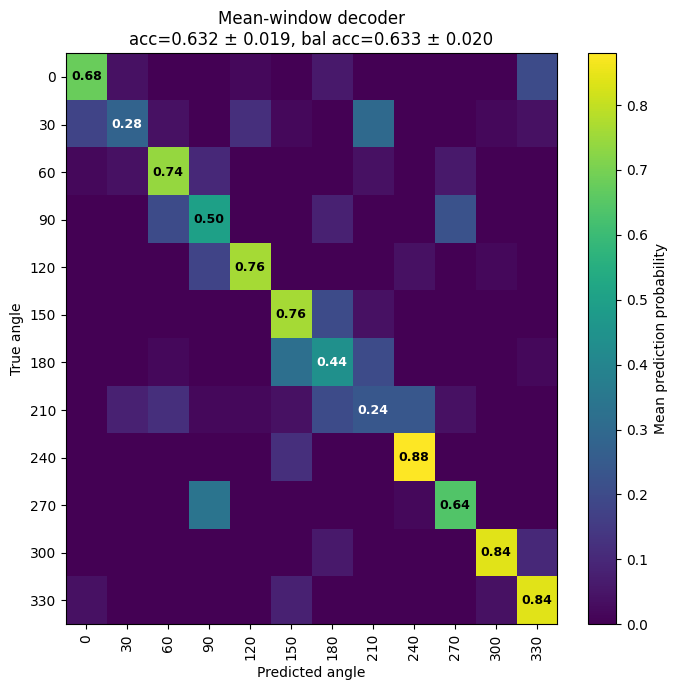

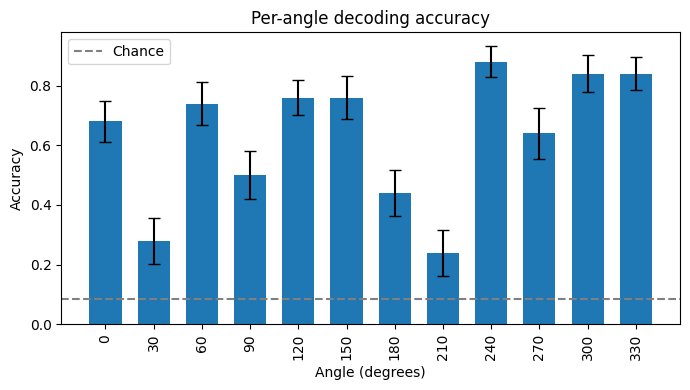

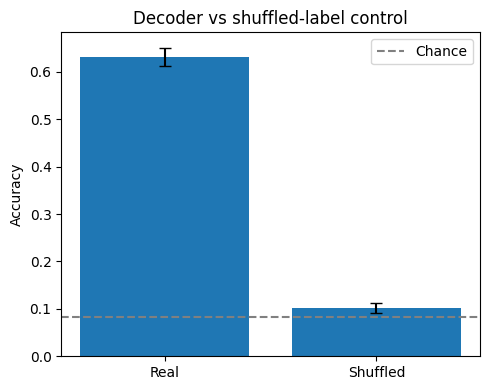

Real accuracy: 0.632 ± 0.018903262505010433
Shuffled accuracy: 0.102 ± 0.011357816691600547
Chance: 0.08333333333333333


In [19]:
main_results = decode_angles(
    stim_data=stim_data,
    baseline_data=iti_data,
    stim_angles=stim_angles,
    stim_start=0,
    stim_end=120,
    base_start=0,
    base_end=50,
    n_splits=25,
    seed_start=0,
    plot=True,
    run_shuffle_control=True,
)

print("Real accuracy:", main_results["mean_acc"], "±", main_results["sem_acc"])
print("Shuffled accuracy:", main_results["mean_shuf_acc"], "±", main_results["sem_shuf_acc"])
print("Chance:", 1 / len(main_results["unique_angles"]))

In [20]:
def decoding_vs_spine_removal(
    X,
    y,
    osi,
    splits,
    unique_angles=None,
    fractions=None,
    plot=True,
):
    if unique_angles is None:
        unique_angles = np.sort(np.unique(y))

    if fractions is None:
        fractions = np.linspace(0, 0.5, 10)

    order = np.argsort(osi)[::-1]

    n_splits = len(splits)
    acc_matrix = np.zeros((n_splits, len(fractions)))
    bacc_matrix = np.zeros((n_splits, len(fractions)))
    n_spines_used = np.zeros(len(fractions), dtype=int)

    for split_idx, (train_idx, test_idx) in enumerate(splits):
        for j, frac in enumerate(fractions):
            n_remove = int(frac * len(order))
            keep = order[n_remove:]
            n_spines_used[j] = len(keep)

            X_sub = X[:, keep]

            res = fit_logreg_on_split(
                X=X_sub,
                y=y,
                unique_angles=unique_angles,
                train_idx=train_idx,
                test_idx=test_idx,
            )

            acc_matrix[split_idx, j] = res["acc"]
            bacc_matrix[split_idx, j] = res["bacc"]

    mean_acc = acc_matrix.mean(axis=0)
    sem_acc = acc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    mean_bacc = bacc_matrix.mean(axis=0)
    sem_bacc = bacc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(fractions * 100, mean_acc, marker="o", label="Accuracy")
        plt.fill_between(fractions * 100, mean_acc - sem_acc, mean_acc + sem_acc, alpha=0.2)

        plt.plot(fractions * 100, mean_bacc, marker="o", label="Balanced accuracy")
        plt.fill_between(fractions * 100, mean_bacc - sem_bacc, mean_bacc + sem_bacc, alpha=0.2)

        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xlabel("% highest OSI spines removed")
        plt.ylabel("Decoding performance")
        plt.title("Decoding vs removing most selective spines")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "fractions": np.array(fractions),
        "n_spines_used": n_spines_used,
        "acc_matrix": acc_matrix,
        "bacc_matrix": bacc_matrix,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
    }

In [21]:
def compute_OSI(stim_data, iti_data, stim_angles):

    stim_start, stim_end = 0, 120
    base_start, base_end = 0, 120

    stim_resp = np.nanmean(stim_data[:, stim_start:stim_end, :], axis=1)
    base_resp = np.nanmean(iti_data[:, base_start:base_end, :], axis=1)
    resp = stim_resp - base_resp
    all_angles = np.asarray(stim_angles)

    unique_angles = np.sort(np.unique(all_angles))

    tuning = np.stack(
        [resp[stim_angles == ang].mean(axis=0) for ang in unique_angles],
        axis=0
    )  # (n_angles, n_spines)

    theta = np.deg2rad(unique_angles)

    R = np.maximum(tuning.T, 0)  # shape: (n_spines, n_angles)

    x = (R * np.cos(2 * theta)).sum(axis=1)
    y = (R * np.sin(2 * theta)).sum(axis=1)
    magnitude = np.sqrt(x**2 + y**2)

    osi = magnitude / (R.sum(axis=1) + 1e-9)

    return resp, all_angles, unique_angles, osi

In [22]:
_, _ , _ , osi = compute_OSI(stim_data, iti_data, stim_angles)

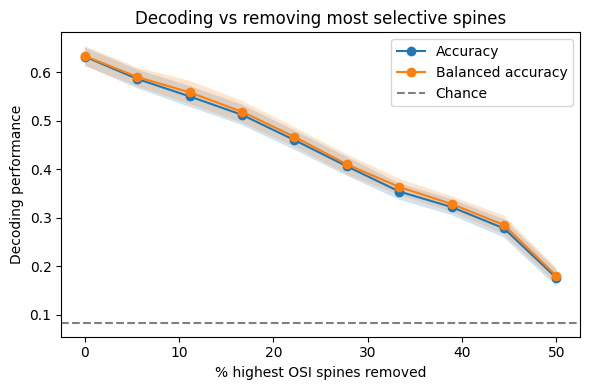

In [23]:
osi_results = decoding_vs_spine_removal(
    X=main_results["X"],
    y=main_results["y"],
    osi=osi,
    splits=main_results["splits"],
    unique_angles=main_results["unique_angles"],
    plot=True,
)

In [24]:
def sliding_window_decode(
    stim_data,
    baseline_data,
    stim_angles,
    splits,
    window_size=10,
    step_size=1,
    base_start=0,
    base_end=None,
    plot=True,
):
    n_trials, n_time, n_spines = stim_data.shape

    if base_end is None:
        base_end = baseline_data.shape[1]

    y = np.asarray(stim_angles)
    unique_angles = np.sort(np.unique(y))

    base_resp = np.nanmean(baseline_data[:, base_start:base_end, :], axis=1)

    starts = np.arange(0, n_time - window_size + 1, step_size)
    centers = starts + window_size / 2

    n_splits = len(splits)
    acc_matrix = np.zeros((n_splits, len(starts)))
    bacc_matrix = np.zeros((n_splits, len(starts)))

    for split_idx, (train_idx, test_idx) in enumerate(splits):
        for j, start in enumerate(starts):
            end = start + window_size

            stim_resp = np.nanmean(stim_data[:, start:end, :], axis=1)
            X = stim_resp - base_resp

            res = fit_logreg_on_split(
                X=X,
                y=y,
                unique_angles=unique_angles,
                train_idx=train_idx,
                test_idx=test_idx,
            )

            acc_matrix[split_idx, j] = res["acc"]
            bacc_matrix[split_idx, j] = res["bacc"]

    mean_acc = acc_matrix.mean(axis=0)
    sem_acc = acc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    mean_bacc = bacc_matrix.mean(axis=0)
    sem_bacc = bacc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if plot:
        plt.figure(figsize=(7, 4))
        plt.plot(centers, mean_acc, label="Accuracy")
        plt.fill_between(centers, mean_acc - sem_acc, mean_acc + sem_acc, alpha=0.2)

        plt.plot(centers, mean_bacc, label="Balanced accuracy")
        plt.fill_between(centers, mean_bacc - sem_bacc, mean_bacc + sem_bacc, alpha=0.2)

        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xlabel("Window center (frames)")
        plt.ylabel("Decoding performance")
        plt.title("Sliding-window decoding")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "window_centers": centers,
        "acc_matrix": acc_matrix,
        "bacc_matrix": bacc_matrix,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
    }

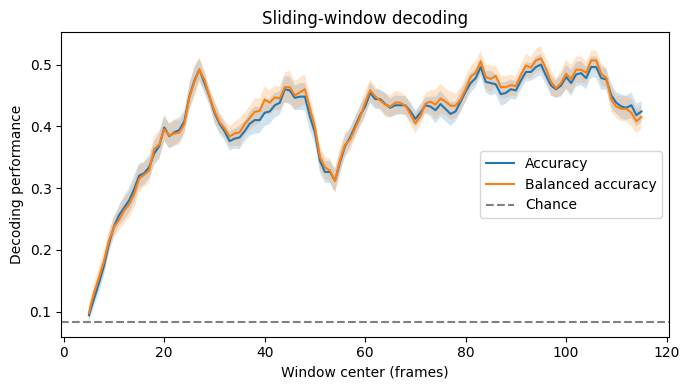

In [25]:
time_results = sliding_window_decode(
    stim_data=stim_data,
    baseline_data=iti_data,
    stim_angles=stim_angles,
    splits=main_results["splits"],
    window_size=10,
    step_size=1,
    base_start=0,
    base_end=50,
    plot=True,
)